## 1. Imports

In [1]:
import os
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib as jbl
from scipy.stats import spearmanr, kendalltau
from matplotlib.lines import Line2D

from zarth_utils.config import Config
from method_runner import MethodRunner
from data_utils import helm_datasets
from benchpred import all_methods
from main import DEFAULT_METHODS

warnings.filterwarnings("ignore", category=UserWarning)
print(f"Registered methods: {len(all_methods)}; DEFAULT_METHODS: {len(DEFAULT_METHODS)}")
print("Available HELM datasets:", helm_datasets)

/home/local/KHQ/edward.wang/code/mrmr_eval/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Registered methods: 153; DEFAULT_METHODS: 12
Available HELM datasets: ['commonsense', 'gsm', 'legalbench', 'math', 'med_qa', 'mmlu', 'narrative_qa', 'natural_qa', 'wmt_14']


## 2. Tutorial configuration

Change the values below to vary the experiment.  `NUM_TRAIN_MODELS` accepts either a single int (1×4 plot) or a list of ints (2×4 plot).

In [2]:
DATASET = "med_qa"                 # categorical HELM task -> works with DKPS one-hot
NUM_SEEDS = 3                             # number of random train/test splits (bump to 3 once it works)
CORESET_SIZES = ["1%", "2%","3%", "4%", "5%", "10%", "15%"]                   # fraction of full benchmark used as coreset
# int -> single 1×4 plot row; list (e.g. [20, 30, 40, 50]) -> 2×4 plot.
NUM_TRAIN_MODELS = [20,30,40,50]

RESULTS_DIR = "./results"
FIXED_CORESET_FOR_BOTTOM_ROW = "1%"        # x-axis fix for the bottom (n_models) row
MODEL_SPLIT_METHOD = "binned_interpolation" # see method_runner._compute_split
MULTI_PROCESS = False                       # set True if you have spare cores
# When MULTI_PROCESS is True, use a single overall progress bar (notebook-friendly).
# Set to "terminal" for per-worker bars, which look better in a plain terminal.
MP_PROGRESS_MODE = "compact" if MULTI_PROCESS else "terminal"

# Default `random_search_and_learn` performs 10 000 search iterations.  For
# tutorial speed we drop that to 1 000 below.  Bump it back up (or remove the
# monkey-patch) if you want the stronger baseline.
RANDOM_SEARCH_ITERS = 1000

## 3. Methods

We start from the paper's `DEFAULT_METHODS` (defined in `main.py`).  `metabench` is excluded by default because it is dramatically slower than every other method even on `ifeval`; uncomment it in `main.py` if you want to include it.  Then we monkey-patch `random_search_and_learn` (and its kernel variant) down to 1 000 iterations so the tutorial completes in a couple of minutes.

In [ ]:
# NOTE: random_search_and_learn defaults to 10,000 search iterations which
# is overkill for a tutorial.  Cap it at RANDOM_SEARCH_ITERS by overriding
# its `fit` default.  Bump `RANDOM_SEARCH_ITERS` if you need the stronger
# baseline.  (Harmless here even though the list below omits it.)
from benchpred.random import RandomSearchAndLearn
_orig_fit = RandomSearchAndLearn.fit
def _fast_fit(self, source_full_scores, coreset_size, seed=42,
              num_search=RANDOM_SEARCH_ITERS, *args, **kwargs):
    return _orig_fit(
        self, source_full_scores, coreset_size,
        num_search=num_search, seed=seed, *args, **kwargs,
    )
RandomSearchAndLearn.fit = _fast_fit

# DKPS + a few mRMR variants + two simple baselines, all on med_qa.
# mRMR keys: mrmr{mi_k}_{MIQ|MID}_y, with an optional "k" prefix for the
# degree-2 kernel-ridge variant (see benchpred/__init__.py).  All are in
# `all_methods` (148 registered).  Add/remove freely.
print(DEFAULT_METHODS)
METHODS = [
    "random_sampling_and_learn",
    "random_sampling",
    "dkps",
    "dkps_mrmr",                # iterative DKPS-guided mRMR (per-target coreset)
    
    "kmrmr5_MIQ_y",              # kernel-ridge (degree-2) variant of mrmr5_MIQ_y
    "dkps+mrmr5_MIQ_y",
    
    "kanchor_points_weighted+",
    "dkps+anchor_points_weighted",
    
    "krandom_search_and_learn",
    
]
print(f"Will run {len(METHODS)} methods:")
for m in METHODS:
    print("  -", m)

## 4. Run the experiments

For every `(num_train_models, coreset_size)` pair we instantiate a `MethodRunner` and call `run_all_datasets`.  Results land in `RESULTS_DIR/<split>/coreset_<size>/nmodels_<n>/<dataset>/<method>/<seed>/result.jbl`; reruns skip combinations that already exist.

In [4]:
def _as_list(x):
    return list(x) if isinstance(x, (list, tuple)) else [x]

nmodels_values = _as_list(NUM_TRAIN_MODELS)

for n_models in nmodels_values:
    for coreset in CORESET_SIZES:
        print(f"\n--- nmodels={n_models}, coreset={coreset} ---")
        cfg = Config(
            default_config_dict={
                "data_source": "helm",
                "datasets": [DATASET],
                "dir_results": RESULTS_DIR,
                "exp_suffix": "",
                "coreset_size": coreset,
                "methods": METHODS,
                "model_split_method": MODEL_SPLIT_METHOD,
                "num_train_models": int(n_models),
                "seed_start": 0,
                "num_run": NUM_SEEDS,
                "multi_process": MULTI_PROCESS,
                "mp_progress_mode": MP_PROGRESS_MODE,
                "use_git": False,
            },
            use_argparse=False,
        )
        MethodRunner(cfg).run_all_datasets()

print("\nAll experiments done.")


--- nmodels=20, coreset=1% ---

=== Running dataset: med_qa ===
  coreset_size=1% -> 10  (num_data=1000)  num_train_models=20  methods=8  seeds=3  trials=24
  [ 1/24] cached  random_sampling_and_learn (seed=0)
  [ 2/24] cached  random_sampling (seed=0)
  [ 3/24] cached  dkps (seed=0)
  [ 4/24] cached  kmrmr5_MIQ_y (seed=0)
  [ 5/24] running dkps+mrmr5_MIQ_y (seed=0)
           done    dkps+mrmr5_MIQ_y (seed=0)  MAE=0.0871  RMSE=0.1129
  [ 6/24] cached  kanchor_points_weighted+ (seed=0)
  [ 7/24] running dkps+anchor_points_weighted (seed=0)
           done    dkps+anchor_points_weighted (seed=0)  MAE=0.0757  RMSE=0.0947
  [ 8/24] cached  krandom_search_and_learn (seed=0)
  [ 9/24] cached  random_sampling_and_learn (seed=1)
  [10/24] cached  random_sampling (seed=1)
  [11/24] cached  dkps (seed=1)
  [12/24] cached  kmrmr5_MIQ_y (seed=1)
  [13/24] running dkps+mrmr5_MIQ_y (seed=1)
  [14/24] running kanchor_points_weighted+ (seed=1)
  [15/24] running dkps+anchor_points_weighted (seed=1)
 

## 5. Aggregate results into a tidy dataframe

Walk the `results/` tree and collect, per `(method, coreset_size, num_train_models)`, the mean RMSE / MAE / Kendall τ / Spearman ρ across seeds.  Each `result.jbl` already contains `error_MAE`, `error_RMSE`, and the full predicted / true accuracies, so we recompute the correlation metrics on the fly for consistency with `combined_grid_continuous_and_pass1_k1_two_row_filtered.pdf` (which uses paired-rank correlations across the *train + test* models).

In [5]:
def _parse_coreset(label: str) -> float:
    label = str(label)
    if label.endswith("%"):
        return float(label[:-1])
    return float(label)

def _correlations(true_train, true_test, pred_train, pred_test):
    """Spearman + Kendall on concatenated train+test predictions."""
    true_all = np.concatenate([np.asarray(true_train), np.asarray(true_test)])
    pred_all = np.concatenate([np.asarray(pred_train), np.asarray(pred_test)])
    if len(true_all) < 2:
        return float("nan"), float("nan")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        rho = float(spearmanr(true_all, pred_all).statistic)
        tau = float(kendalltau(true_all, pred_all).statistic)
    return rho, tau

def collect_results(results_dir: str, split: str, dataset: str) -> pd.DataFrame:
    rows = []
    skipped_stale = 0
    base = Path(results_dir) / split
    for coreset_dir in sorted(base.glob("coreset_*")):
        coreset = coreset_dir.name.replace("coreset_", "")
        for nmodels_dir in sorted(coreset_dir.glob("nmodels_*")):
            n_models = nmodels_dir.name.replace("nmodels_", "")
            ds_dir = nmodels_dir / dataset
            if not ds_dir.is_dir():
                continue
            for method_dir in sorted(ds_dir.iterdir()):
                if not method_dir.is_dir():
                    continue
                for seed_dir in sorted(method_dir.iterdir()):
                    result_path = seed_dir / "result.jbl"
                    if not result_path.is_file():
                        continue
                    r = jbl.load(result_path)
                    # Defensive: drop stale result files from older buggy runs
                    # (sklearn used to propagate the bool dtype through Ridge,
                    # producing MAE ~ 0.65 with prediction arrays of all True).
                    pred_arr = np.asarray(r["pred_acc_train"])
                    if pred_arr.dtype == bool:
                        skipped_stale += 1
                        continue
                    rho, tau = _correlations(
                        r["true_acc_train"], r["true_acc_test"],
                        r["pred_acc_train"], r["pred_acc_test"],
                    )
                    rows.append({
                        "method": method_dir.name,
                        "coreset_size": coreset,
                        "num_train_models": int(n_models),
                        "seed": int(seed_dir.name),
                        "mae": 100.0 * float(r["error_MAE"]),
                        "rmse": 100.0 * float(r["error_RMSE"]),
                        "tau": tau,
                        "rho": rho,
                    })
    if skipped_stale:
        print(
            f"  (skipped {skipped_stale} stale bool-pred result.jbl files from "
            "pre-fix runs; delete `results/` or re-run them to regenerate)"
        )
    return pd.DataFrame(rows)

def summarise(df: pd.DataFrame) -> pd.DataFrame:
    keys = ["method", "coreset_size", "num_train_models"]
    summary = (
        df.groupby(keys, as_index=False)[["rmse", "mae", "tau", "rho"]]
        .mean()
    )
    summary["coreset_size_pct"] = summary["coreset_size"].map(_parse_coreset)
    return summary.sort_values(keys).reset_index(drop=True)

def warn_incomplete_coverage(summary: pd.DataFrame, methods: list[str],
                              coreset_sizes: list[str],
                              nmodels: list[int]) -> None:
    """Print a brief warning for any (method, coreset, nmodels) cell that has
    no data.  Helps explain missing points / lines in the plot below."""
    expected = {
        (m, c, int(n)) for m in methods for c in coreset_sizes for n in nmodels
    }
    have = {
        (row["method"], row["coreset_size"], int(row["num_train_models"]))
        for _, row in summary.iterrows()
    }
    missing = sorted(expected - have)
    if not missing:
        return
    print(f"  WARNING: {len(missing)} (method, coreset, nmodels) cells are missing:")
    by_method: dict[str, list[str]] = {}
    for m, c, n in missing:
        by_method.setdefault(m, []).append(f"({c}, nm={n})")
    for m in sorted(by_method):
        cells = ", ".join(by_method[m])
        print(f"    - {m:<30s} missing: {cells}")
    print("  Re-run the experiment cell (or fix any errors logged in logs/) to fill them in.")

raw = collect_results(RESULTS_DIR, MODEL_SPLIT_METHOD, DATASET)
summary = summarise(raw)
print(f"Loaded {len(raw)} trial rows  →  {len(summary)} aggregated rows")
warn_incomplete_coverage(
    summary,
    methods=METHODS,
    coreset_sizes=CORESET_SIZES,
    nmodels=_as_list(NUM_TRAIN_MODELS),
)
summary.head(12)

Loaded 888 trial rows  →  368 aggregated rows


,method,coreset_size,num_train_models,rmse,mae,tau,rho,coreset_size_pct
0,anchor_points_weighted,1%,20,13.228295,10.938095,0.695509,0.852509,1.0
1,anchor_points_weighted,1%,30,12.010318,9.692452,0.746672,0.894860,1.0
2,anchor_points_weighted,1%,40,14.266150,12.462791,0.786661,0.926244,1.0
3,anchor_points_weighted,1%,50,12.855184,11.345455,0.801797,0.921842,1.0
4,anchor_points_weighted,10%,20,3.909772,3.157672,0.884454,0.978376,10.0
5,anchor_points_weighted,10%,30,4.846007,4.086164,0.889382,0.979681,10.0
6,anchor_points_weighted,10%,40,3.902149,3.182171,0.896068,0.980824,10.0
7,anchor_points_weighted,10%,50,3.914021,3.333333,0.902768,0.984675,10.0
8,anchor_points_weighted,15%,20,3.421413,2.827513,0.903400,0.985131,15.0
9,anchor_points_weighted,15%,30,3.846260,3.269183,0.909163,0.985558,15.0


## 6. Plotting helpers

A small, self-contained `method_style()` keeps the visual conventions of the paper (Ridge = solid, KRR = dashed, distinct colour per method family) without depending on the much heavier `mrmr/viz/notebooks/nb_utils.py`.

In [ ]:
# Methods to omit from the plot, e.g. when the legend gets too crowded.
# Defaults to empty so every method run actually shows up; the "filtered"
# variant of the paper figure drops the slower learning baselines, e.g.:
#     EXCLUDE_FROM_PLOT = {"random_search_and_learn", "random_sampling_and_learn"}
EXCLUDE_FROM_PLOT: set[str] = set()

_METHOD_COLOURS = {
    "mrmr":           "#e91e63",  # pink
    "irt":            "#2e7d32",  # green
    "anchor":         "#6d4c41",  # brown
    "random_sample":  "#c7c7c7",  # light grey
    "random_sampling_and_learn":  "#7f7f7f",  # dark grey
    "random_search":  "#000000",  # black
    "lasso":          "#64b5f6",  # grey
    "metabench":      "#7b1fa2",  # olive
    "dkps":           "#ff7f0e",  # orange
    "dkps_mrmr":      "#17becf",  # teal
    "other":          "#616161",  # grey
}
_METHOD_MARKERS = {
    "mrmr":          "*",
    "irt":           "s",
    "anchor":        "p",
    "random_sample": "^",
    "random_sampling_and_learn": "^",
    "random_search": "^",
    "lasso":         "o",
    "metabench":     "D",
    "dkps":          "X",
    "dkps_mrmr":     "P",
    "other":         "o",
}

def _kernel_degree(name: str) -> int:
    """Return the KRR polynomial degree implied by the method-key prefix."""
    if name.startswith("k3"):
        return 3
    if name.startswith("k4"):
        return 4
    if name.startswith("k"):
        return 2
    return 1

def _strip_kernel_prefix(name: str) -> str:
    for p in ("k3", "k4", "k"):
        if name.startswith(p):
            return name[len(p):]
    return name

def _method_family(name: str) -> str:
    # DKPS-mRMR is its own family (distinct teal colour / "P" marker); check it
    # before the generic "dkps" prefix below so it does not collapse into DKPS.
    if name.startswith("dkps_mrmr"):
        return "dkps_mrmr"
    # DKPS first: dkps / dkps_google / dkps+<base> all map here, even when the
    # base name contains another family's keyword (e.g. dkps+gpirt1).
    if name.startswith("dkps"):
        return "dkps"
    base = _strip_kernel_prefix(name)
    if base.startswith("mrmr"):
        return "mrmr"
    if base.startswith("random_sampling_"):
        return "random_sampling_and_learn"
    if base == "random_sampling":
        return "random_sample"
    if "random_search" in base or "small_search" in base:
        return "random_search"
    if base.startswith("anchor_points"):
        return "anchor"
    if "pirt" in base or "gpirt" in base:
        return "irt"
    if base == "lasso":
        return "lasso"
    if base == "metabench":
        return "metabench"
    return "other"

def _mi_k_from_mrmr(name: str) -> int:
    base = _strip_kernel_prefix(name)
    if base.startswith("mrmr_"):
        return 3
    if base.startswith("mrmr"):
        for k in range(9, 3, -1):
            if base.startswith(f"mrmr{k}_"):
                return k
    return 3

def _dkps_base(name: str) -> str:
    """The base method a DKPS variant borrows its coreset from ('' if random)."""
    return name.split("+", 1)[1] if "+" in name else ""

def method_style(name: str) -> dict:
    family = _method_family(name)
    degree = _kernel_degree(name)
    if family == "dkps_mrmr":
        # Distinct teal "P" so DKPS-mRMR reads apart from plain DKPS (orange X);
        # dashed line flags the Gemini embedder, matching the DKPS convention.
        return {
            "color": _METHOD_COLOURS["dkps_mrmr"],
            "marker": _METHOD_MARKERS["dkps_mrmr"],
            "linestyle": "--" if "google" in name else "-",
            "linewidth": 1.6,
            "markersize": 7,
            "alpha": 1.0,
        }
    if family == "dkps":
        # All DKPS variants share the orange family colour.  The marker encodes
        # the coreset source (plain DKPS -> "X", else the base method's marker),
        # and a dashed line flags the Gemini embedder -- so dkps, dkps_google,
        # dkps+mrmr5_MIQ_y and dkps+anchor_points_weighted are all distinct.
        base = _dkps_base(name)
        marker = _METHOD_MARKERS[_method_family(base)] if base else "X"
        return {
            "color": _METHOD_COLOURS["dkps"],
            "marker": marker,
            "linestyle": "--" if "google" in name else "-",
            "linewidth": 1.6,
            "markersize": 7,
            "alpha": 1.0,
        }
    return {
        "color": _METHOD_COLOURS[family],
        "marker": _METHOD_MARKERS[family],
        "linestyle": "-" if degree == 1 else "--",
        "linewidth": 1.6,
        "markersize": 6,
        "alpha": 1.0 if "+" not in name else 0.7,
    }

def pretty_label(name: str) -> str:
    family = _method_family(name)
    degree = _kernel_degree(name)
    suffix = "+" if "+" in name else ""
    suffix += "" if degree == 1 else " (d=2)" if degree == 2 else f" (d={degree})"
    if family == "dkps_mrmr":
        tail = name[len("dkps_mrmr"):].lstrip("_")  # "", "k5", "MIQ", "google", ...
        return "DKPS-mRMR" + (f" ({tail})" if tail else "")
    if family == "dkps":
        label = "DKPS (Gemini)" if "google" in name else "DKPS"
        if "+" in name:
            label += " on " + name.split("+", 1)[1]
        return label
    if family == "mrmr":
        base = _strip_kernel_prefix(name)
        scheme = "MIQ" if "_MIQ_" in base else "MID" if "_MID_" in base else ""
        mi_k = _mi_k_from_mrmr(name)
        return f"mRMR {scheme} (k={mi_k}){suffix}"
    if family == "irt":
        base = _strip_kernel_prefix(name)
        for k in ("1", "5"):
            if base.endswith(k):
                return f"gp-IRT (p={k}){suffix}"
        return f"gp-IRT{suffix}"
    if family == "anchor":
        base_label = (
            "AnchorPts" if "anchor_points_weighted" in name
            else "AnchorPts (predictor)"
        )
        return f"{base_label}{suffix}"
    if family == "random_sample":
        base_label = "Random+" if "and_learn" in name else "Random"
        return f"{base_label}{suffix}"
    if family == "random_search":
        return f"Search+{suffix}"
    if family == "lasso":
        return "Lasso"
    if family == "metabench":
        return "MetaBench"
    return name

def _aggregate_per_method(name: str) -> str:
    """Collapse multiple mRMR mi_k variants to a single legend line per (family, degree)."""
    if _method_family(name) == "mrmr":
        degree = _kernel_degree(name)
        scheme = "MIQ" if "_MIQ_" in name else "MID" if "_MID_" in name else "MI"
        return f"mrmr_{scheme}_d{degree}"
    return name

print("Method-style helpers defined.")

## 7. Recreate `combined_grid_continuous_and_pass1_k1_two_row_filtered.pdf`

The plot mirrors the structure of [`mrmr/viz/plots/03_combined_grids/combined_grid_continuous_and_pass1_k1_two_row_filtered.pdf`](../../mrmr/viz/plots/03_combined_grids/combined_grid_continuous_and_pass1_k1_two_row_filtered.pdf): one row of `(RMSE, MAE, Kendall τ, Spearman ρ)` curves vs. coreset size, with a second row vs. number of source models when a list of `num_train_models` is provided.

By default `EXCLUDE_FROM_PLOT` is empty so every method you actually ran will appear in the plot.  To reproduce the paper's "filtered" view (which drops the slower learning baselines so the headline methods stand out), set e.g. `EXCLUDE_FROM_PLOT = {"random_search_and_learn", "random_sampling_and_learn"}` in the helpers cell above.

Saved figure to plots/combined_grid_med_qa_filtered.pdf


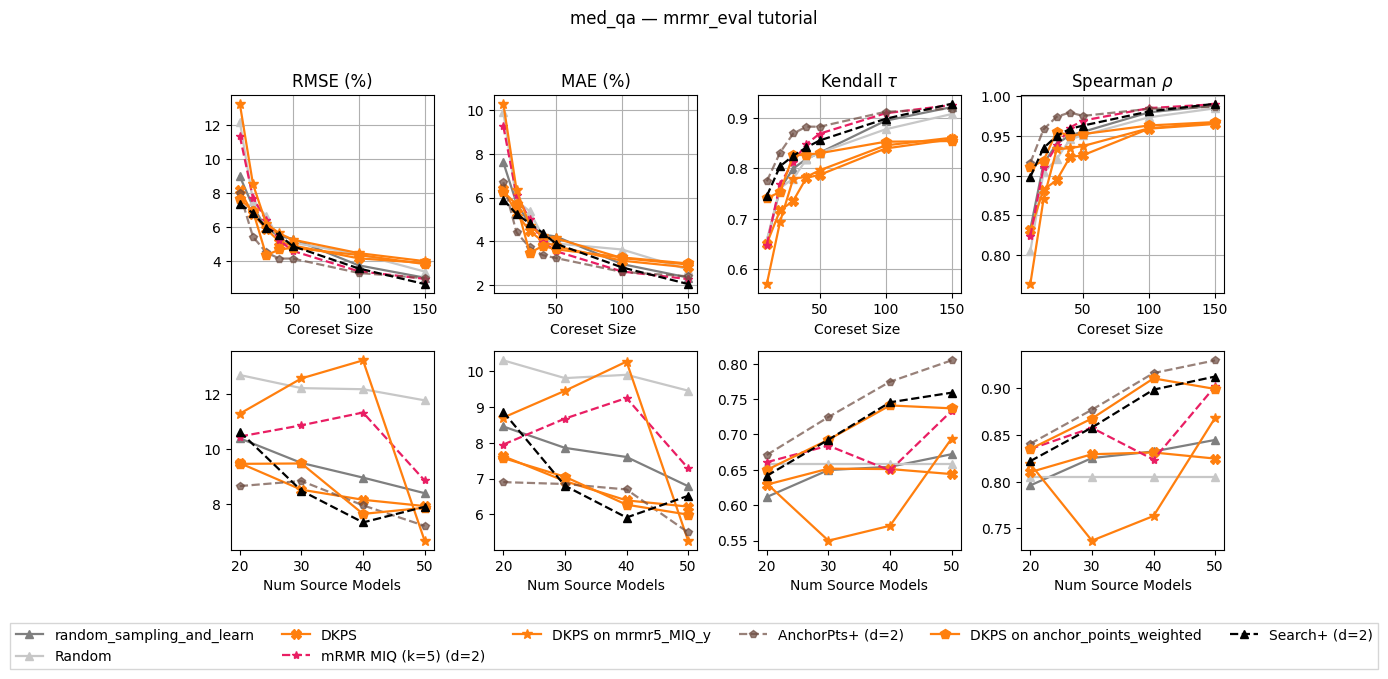

In [9]:
METRIC_TITLES = {
    "rmse": "RMSE (%)",
    "mae":  "MAE (%)",
    "tau":  r"Kendall $\tau$",
    "rho":  r"Spearman $\rho$",
}

def _frame_at_fixed_nmodels(summary: pd.DataFrame, nmodels: int) -> pd.DataFrame:
    sub = summary[summary["num_train_models"] == int(nmodels)].copy()
    sub["x_value"] = sub["coreset_size_pct"]*1000/100
    return sub

def _frame_at_fixed_coreset(summary: pd.DataFrame, coreset: str) -> pd.DataFrame:
    sub = summary[summary["coreset_size"] == coreset].copy()
    sub["x_value"] = sub["num_train_models"].astype(float)
    return sub

def _plot_panel(ax, frame: pd.DataFrame, metric: str, methods: list[str]):
    for method in methods:
        mf = frame[frame["method"] == method].sort_values("x_value")
        if mf.empty:
            continue
        style = method_style(method)
        ax.plot(
            mf["x_value"].to_numpy(),
            mf[metric].to_numpy(),
            label=pretty_label(method),
            **style,
        )

def _legend_handles(methods: list[str]) -> list[Line2D]:
    seen: dict[str, Line2D] = {}
    for method in methods:
        key = _aggregate_per_method(method)
        if key in seen:
            continue
        style = method_style(method)
        seen[key] = Line2D(
            [0], [0],
            color=style["color"],
            alpha=style["alpha"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=style["markersize"],
            label=pretty_label(method),
        )
    return list(seen.values())

def plot_combined_grid(
    summary: pd.DataFrame,
    methods: list[str],
    *,
    nmodels: int | list[int],
    coreset_for_bottom_row: str,
    title: str | None = None,
    output_path: str | os.PathLike | None = None,
    figsize_per_row=(11.0, 2.6),
):
    methods = [m for m in methods if m not in EXCLUDE_FROM_PLOT and m in set(summary["method"])]
    metrics = ["rmse", "mae", "tau", "rho"]
    multi = isinstance(nmodels, (list, tuple)) and len(nmodels) > 1
    nrows = 2 if multi else 1
    nmodels_list = list(nmodels) if isinstance(nmodels, (list, tuple)) else [nmodels]
    fixed_nmodels = nmodels_list[len(nmodels_list) // 2]

    fig, axes = plt.subplots(
        nrows, 4,
        figsize=(figsize_per_row[0], figsize_per_row[1] * nrows + 1.6),
        constrained_layout=False,
        squeeze=False,
    )

    top = _frame_at_fixed_nmodels(summary, fixed_nmodels)
    for col, metric in enumerate(metrics):
        ax = axes[0, col]
        _plot_panel(ax, top, metric, methods)
        ax.set_xlabel("Coreset Size ")
        ax.set_title(METRIC_TITLES[metric])
        # if col == 0:
        #     ax.annotate(
        #         "(a)", xy=(-0.18, 0.5), xycoords="axes fraction",
        #         ha="right", va="center", fontsize=11, fontweight="bold",
        #     )
        ax.grid(True, "both")

    if multi:
        bottom = _frame_at_fixed_coreset(summary, coreset_for_bottom_row)
        for col, metric in enumerate(metrics):
            ax = axes[1, col]
            _plot_panel(ax, bottom, metric, methods)
            ax.set_xlabel("Num Source Models")
            # if col == 0:
            #     ax.annotate(
            #         "(b)", xy=(-0.18, 0.5), xycoords="axes fraction",
            #         ha="right", va="center", fontsize=11, fontweight="bold",
            #     )

    if title is not None:
        fig.suptitle(title, y=0.98)

    handles = _legend_handles(methods)
    legend_ncol = max(1, min(6, len(handles)))
    fig.tight_layout(rect=(0.04, 0.10 if multi else 0.18, 1.0, 0.96 if title else 0.99))
    # fig.tight_layout()
    fig.legend(
        handles=handles,
        ncol=legend_ncol,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        frameon=True,
        fancybox=False,
    )

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, bbox_inches="tight")
        print(f"Saved figure to {output_path}")
    return fig

fig = plot_combined_grid(
    summary,
    methods=METHODS,
    nmodels=NUM_TRAIN_MODELS,
    coreset_for_bottom_row=FIXED_CORESET_FOR_BOTTOM_ROW,
    title=f"{DATASET} — mrmr_eval tutorial",
    output_path=f"plots/combined_grid_{DATASET}_filtered.pdf",
)
plt.show()

## 8. Inspect a single mRMR coreset

As a sanity check, here are the question indices selected by `mrmr_MIQ_y` (the default mRMR variant) at the smallest coreset size and the first seed.

In [8]:
smallest = sorted(CORESET_SIZES, key=_parse_coreset)[0]
fixed_nmodels_show = _as_list(NUM_TRAIN_MODELS)[0]
result_path = (
    Path(RESULTS_DIR) / MODEL_SPLIT_METHOD / f"coreset_{smallest}"
    / f"nmodels_{fixed_nmodels_show}" / DATASET / "mrmr5_MIQ_y" / "0" / "result.jbl"
)
if result_path.is_file():
    r = jbl.load(result_path)
    print(f"coreset (size={len(r['coreset_indices'])}):")
    print(r["coreset_indices"][:20], "...")
    print(f"train MAE: {r['error_MAE']:.4f}  RMSE: {r['error_RMSE']:.4f}")
else:
    print(f"No result file at {result_path}")

coreset (size=10):
[397, 649, 543, 139, 747, 199, 750, 189, 73, 14] ...
train MAE: 0.0826  RMSE: 0.1062
